# Days 3-4: Intro to Search

This contains the code we went over on day 3 with some additions. (Day 4 stuff can be found later on.)


A couple Jupyter notebook tips. There are two modes when using the notebook: command and edit. While in command mode, you can navigate up and down through the cells with the arrow keys. To edit a cell, press `Enter` to enter edit mode and begin typing. Clicking inside a textbox also starts edit mode. Press `esc` to exit out of edit mode.

A few additional hotkeys/tricks for command mode:

- `Shift + Enter` runs the cell and moves you down. If there is no cell after, it creates an empty cell. The "play" triangle button does the same thing.
- `Ctrl + Enter` runs the cell but doesn't move you down.
- `00`: restart the kernel. This will delete the Python session, so the variables in your memory will be lost. 
- `c`: copy a cell.
- `v`: paste a cell.
- `dd`: delete a cell.
- `z`: undo deletion.

In [1]:
# This imports everything in maze.py
from maze import *

In [2]:
print_maze(maze1)

#############
#S....#.....#
#.##..#.###.#
#..#......#.#
##.#####.##.#
#......#...G#
#############


Visualize with the ```plot_maze``` function.

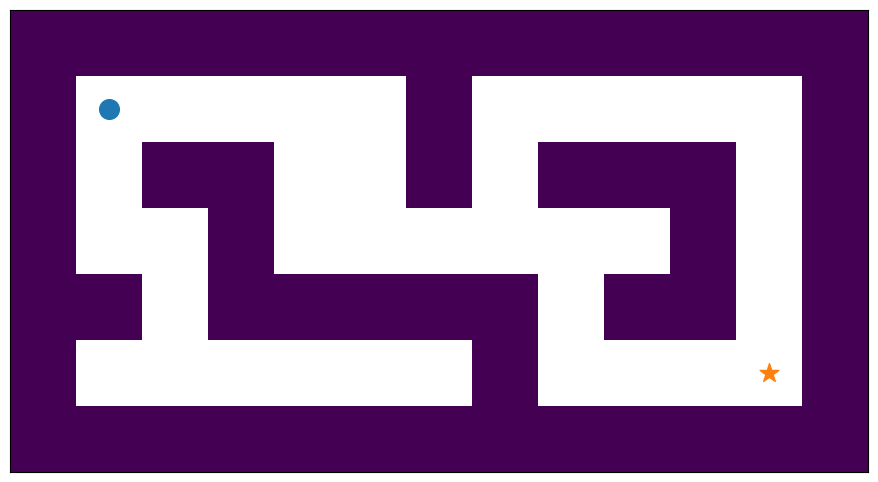

In [3]:
plot_maze(maze1)

Define initial and goal states

In [4]:
initial_state = find_symbol(maze1, 'S')
goal_state = find_symbol(maze1, 'G')
print(initial_state)
print(goal_state)

(1, 1)
(5, 11)


### Breadth-first search

In [5]:
from collections import deque

def breadthFirstSearch(maze, start, goal):
    ''' Find a path from start to goal. use breadth-first search.'''

    frontier = deque([start])
    parent = {start : None}
    expanded = []

    while frontier: # keep going while any nodes in frontier
        state = frontier.popleft() # First in first out
        expanded.append(state)

        if state == goal:
            return expanded
            
        for next_state in get_neighbors(maze, state):
            if next_state not in parent:
                parent[next_state] = state
                frontier.append(next_state)

    return 0
            
        

In [6]:
breadthFirstSearch(maze1, initial_state, goal_state)

[(1, 1),
 (2, 1),
 (1, 2),
 (3, 1),
 (1, 3),
 (3, 2),
 (1, 4),
 (4, 2),
 (2, 4),
 (1, 5),
 (5, 2),
 (3, 4),
 (2, 5),
 (5, 1),
 (5, 3),
 (3, 5),
 (5, 4),
 (3, 6),
 (5, 5),
 (3, 7),
 (5, 6),
 (2, 7),
 (3, 8),
 (1, 7),
 (4, 8),
 (3, 9),
 (1, 8),
 (5, 8),
 (1, 9),
 (5, 9),
 (1, 10),
 (5, 10),
 (1, 11),
 (5, 11)]

The above code keeps expanding the frontier until the goal state is found, but we haven't extracted the path. We will use the parent dictionary to retrace our steps using a helper function `reconstruct_path`.

In [7]:
def reconstruct_path(parent, goal):
    """ Backtrack from goal to start and return path. """
    path = []
    state = goal

    # keep looping until None which means state is start
    while state is not None: 
        path.append(state)
        state = parent[state]

    path.reverse()
    return path
    

In [8]:
from collections import deque

def breadthFirstSearch(maze, start, goal):
    ''' Find a path from start to goal. use breadth-first search.'''

    frontier = deque([start])
    parent = {start : None}
    expanded = []

    while frontier: # keep going while any nodes in frontier
        state = frontier.popleft()
        expanded.append(state)

        if state == goal:
            path = reconstruct_path(parent, goal)
            return path, expanded
            
        for next_state in get_neighbors(maze, state):
            if next_state not in parent:
                parent[next_state] = state
                frontier.append(next_state)

    return 0, expanded

In [9]:
path, expanded = breadthFirstSearch(maze1, initial_state, goal_state)

Let's see if it works:

In [10]:
path

[(1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (2, 4),
 (3, 4),
 (3, 5),
 (3, 6),
 (3, 7),
 (3, 8),
 (4, 8),
 (5, 8),
 (5, 9),
 (5, 10),
 (5, 11)]

The path is extracted as a list. Use the `plot_search` function to visualize.

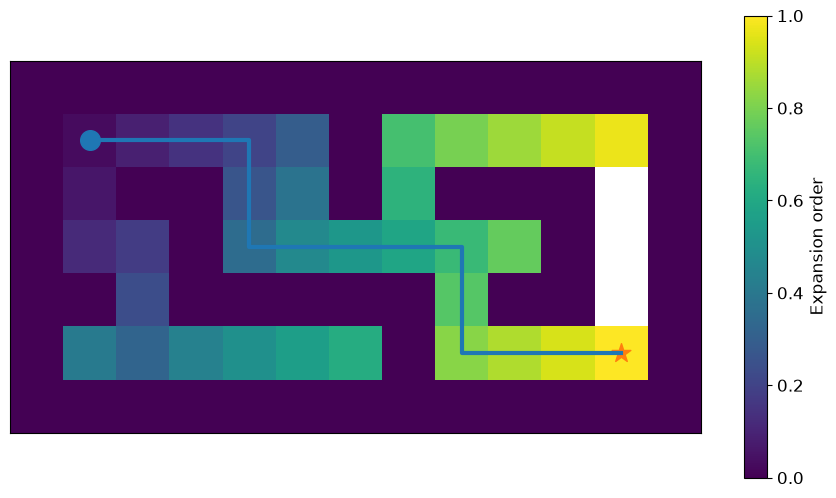

In [11]:
plot_search(maze1, expanded, path)

Notice that this provide a visualization of the order in which states are expanded as well as the final path discovered.

Next steps: 
1. Run the algorithm for maze2 and maze3.
2. Analyze the strengths and weaknesses of bfs.
3. Now imagine going all the way down one path until we hit a dead end, then going back and trying another path, etc. This approach would be called depth-first search: expand the deepest node so far, rather than the shallowest. How do we implement this?

# Day 4: continuing search

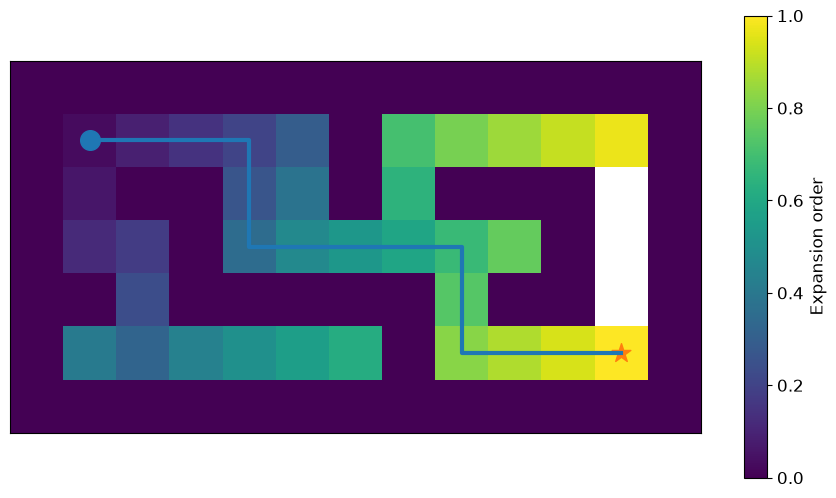

In [12]:
maze = maze1
path, expanded = breadthFirstSearch(maze, find_symbol(maze, 'S'), find_symbol(maze, 'G'))
plot_search(maze, expanded, path)

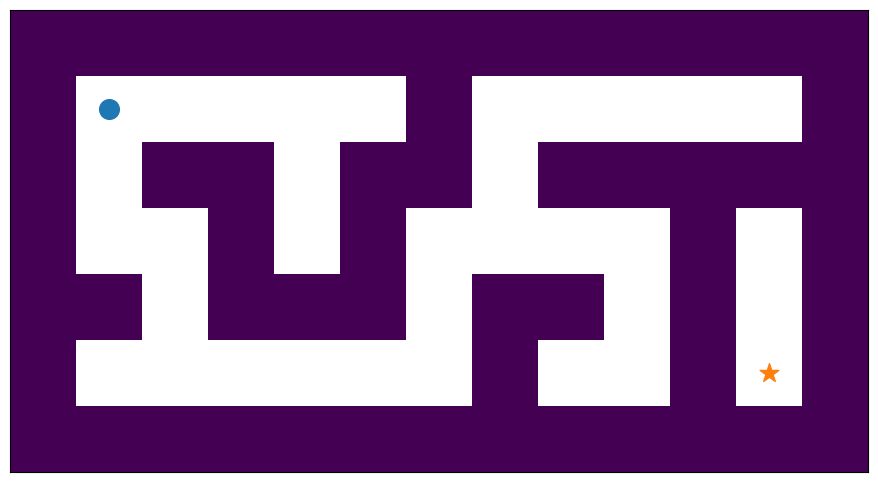

In [13]:
plot_maze(maze3)

In [14]:

def depthFirstSearch(maze, start, goal):
    ''' Find a path from start to goal. use depth-first search.'''

    frontier = deque([start])
    parent = {start : None}
    expanded = []

    while frontier: # keep going while any nodes in frontier
        state = frontier.pop()
        expanded.append(state)

        if state == goal:
            path = reconstruct_path(parent, goal)
            return path, expanded
            
        for next_state in get_neighbors(maze, state):
            if next_state not in parent:
                parent[next_state] = state
                frontier.append(next_state)

    return 0, expanded

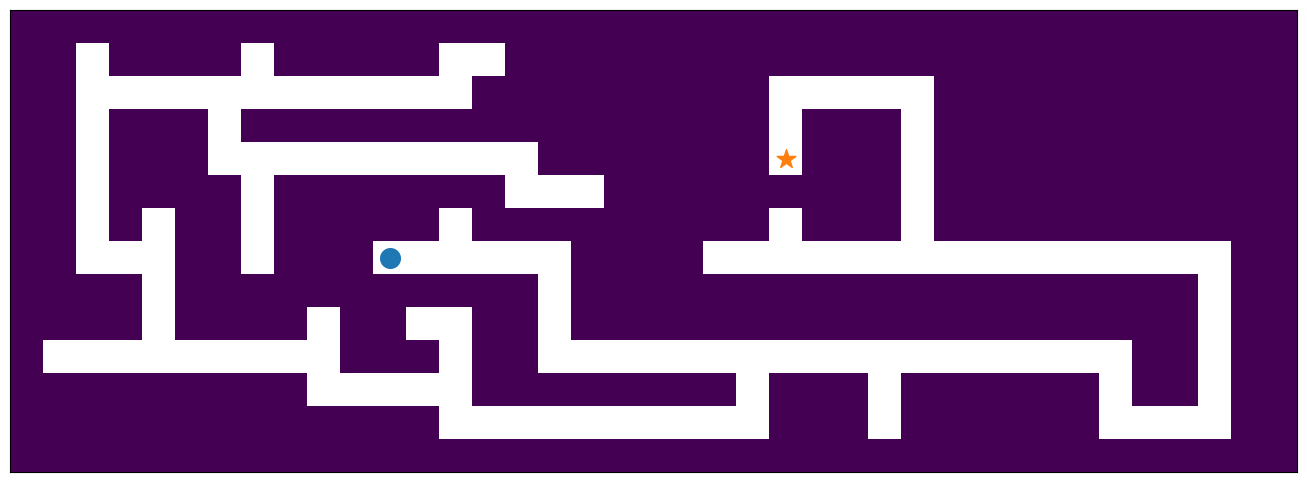

In [15]:
plot_maze(maze11)

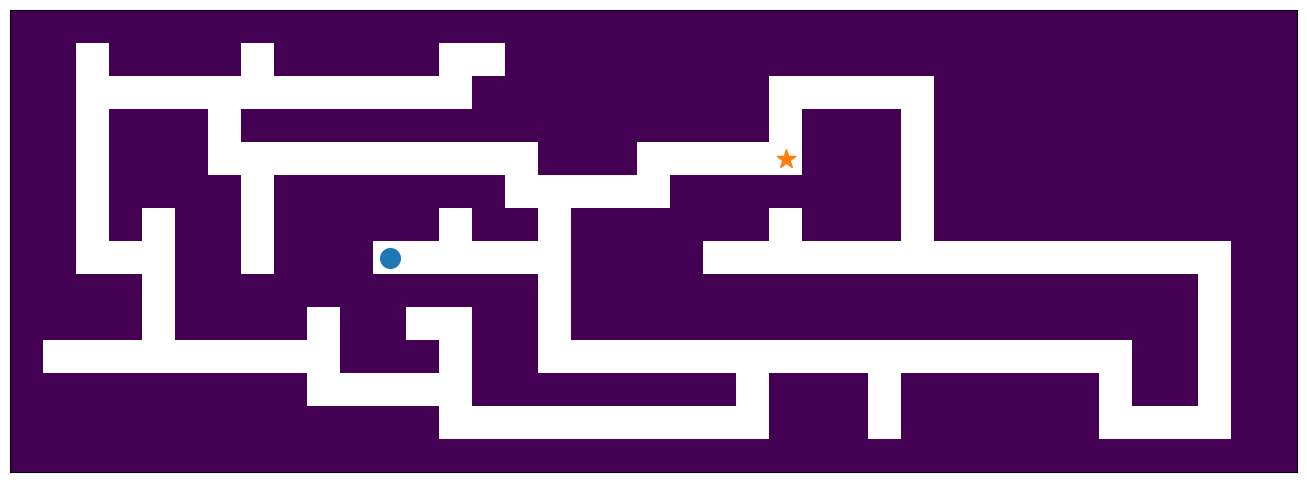

In [16]:
plot_maze(maze12)

## maze11 solution

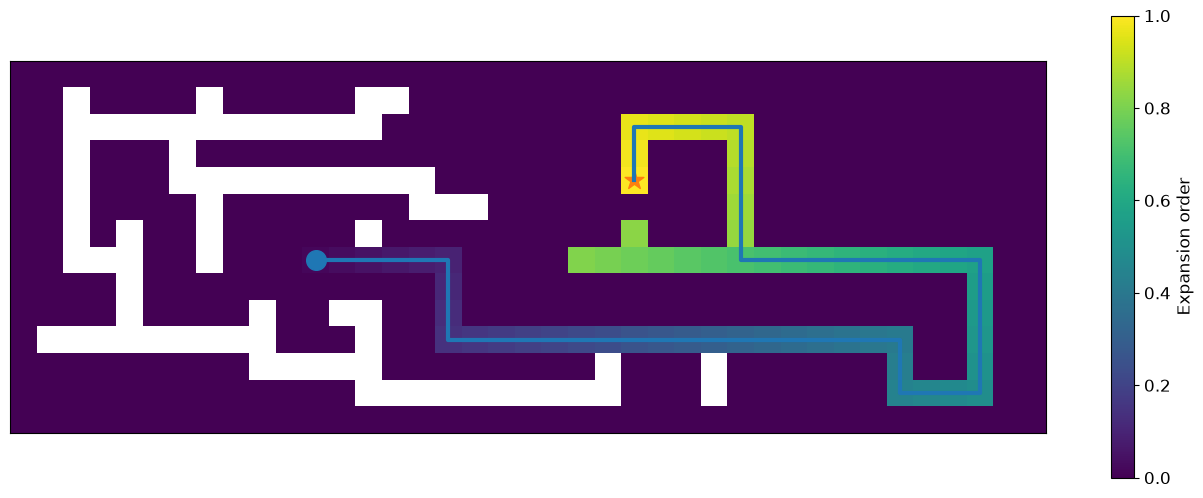

In [17]:
maze = maze11
path, expanded = depthFirstSearch(maze, find_symbol(maze, 'S'), find_symbol(maze, 'G'))
plot_search(maze, expanded, path)

## maze12 solution

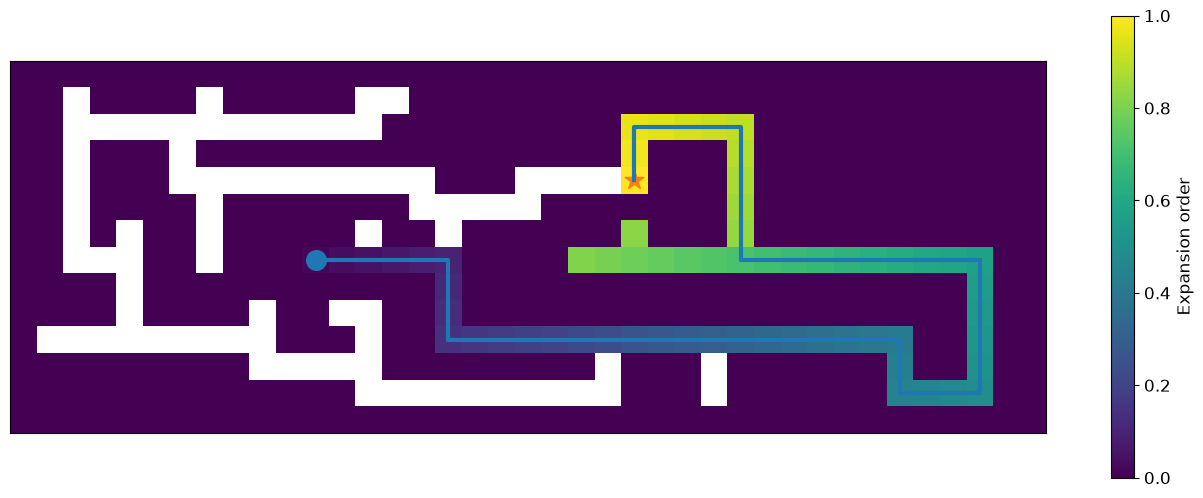

In [18]:
maze = maze12
path, expanded = depthFirstSearch(maze, find_symbol(maze, 'S'), find_symbol(maze, 'G'))
plot_search(maze, expanded, path)

## Let's run again with bfs

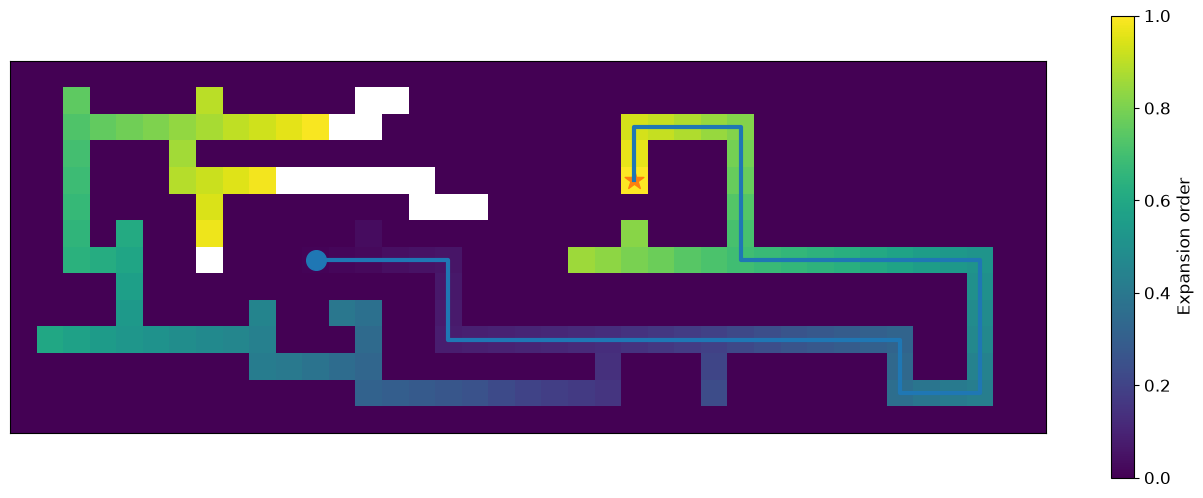

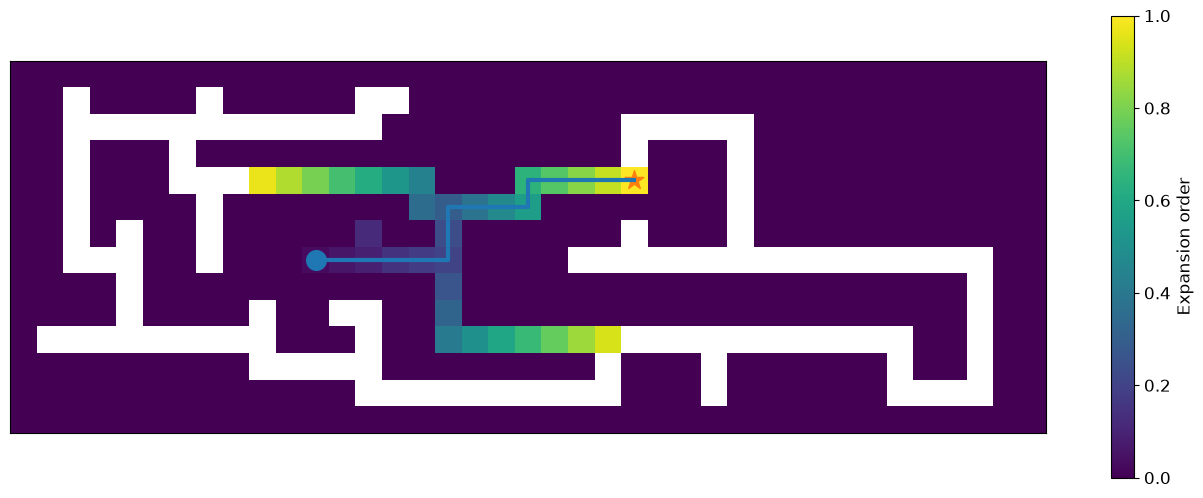

In [19]:
for maze in [maze11, maze12]:
    path, expanded = breadthFirstSearch(maze, find_symbol(maze, 'S'), find_symbol(maze, 'G'))
    plot_search(maze, expanded, path)

In [22]:

maze13 = [
'#######################################',
'##.####.#####..########################',
'##............#########.....###########',
'##.###.################.###.###########',
'##.###..........###...#.###.###########',
'##.####.#######.....###.###.###########',
'##.#.##.#####.##.######.###.###########',
'##...##G###S.....####................##',
'####.###########.###################.##',
'####.####.##..##.###################.##',
'#.........###.##..................##.##',
'#########.....########.###.######.##.##',
'#############..........###.######....##',
'#######################################',]

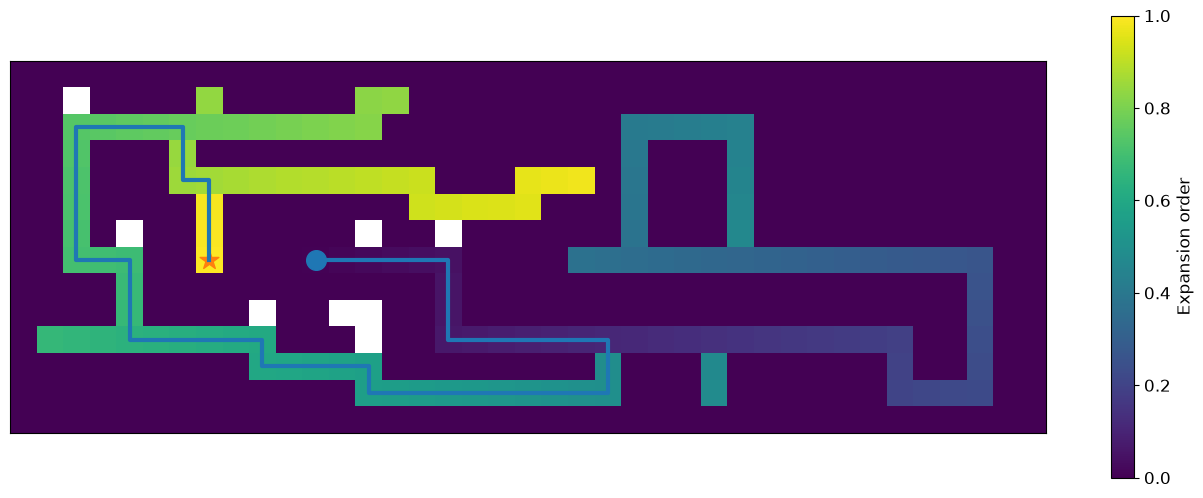

In [23]:
maze = maze13
path, expanded = depthFirstSearch(maze, find_symbol(maze, 'S'), find_symbol(maze, 'G'))
plot_search(maze, expanded, path)

## NEXT STEPS:

Make sure your lab work is pushed to the github repo.

Make sure you get started on the reading (AIMA, Sections 3.1-3.5). Before we get to the next algorithm and more complex settings, it is a good time to start thinking about class structure. Generally, we can distinguish the problem and the algorithm. The problem consists of:

```
initial states
goal state
actions allowed given a state
some mapping from current state + action taken to the resulting state
```

While the algorithm may contain things like
```
frontier
expansion, parent (state search tree)
list of visited nodes
```

We would like to create a Problem class that we can use to interface with different algorithms. A good starting point would be something like:

```
class Problem:

    def initial_state(self):
        "Returns the initial state"

    def actions(self, state):
        Returns possible actions from state

    def result(self, state, action):
        returns resulting state of action from state

    def is_goal(self, state):
        if state is goal, return True
```

For now, just think about how you would implement this class for the maze problem. For a refresher on Python classes, see: https://docs.python.org/3/tutorial/classes.html